## Imports and Connection

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv
from pathlib import Path
import psycopg2

env_path = Path("..") / ".env"
load_dotenv(dotenv_path=env_path)

conn = psycopg2.connect(
    host=os.getenv("DB_HOST"),
    database=os.getenv("DB_NAME"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD")
)

## KPI Overview

In [11]:
query = """
SELECT *
FROM analytics.v_kpi_overview
"""

df_kpi = pd.read_sql(query, conn)
df_kpi

C:\Users\behlu\AppData\Local\Temp\ipykernel_15604\3114821183.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_kpi = pd.read_sql(query, conn)


,total_shipments,avg_lead_time,disruptions,avg_reliability
0,5000,19.355386,3063,0.754387


## Transport Performance

C:\Users\behlu\AppData\Local\Temp\ipykernel_15604\4268506749.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_transport = pd.read_sql(query, conn)


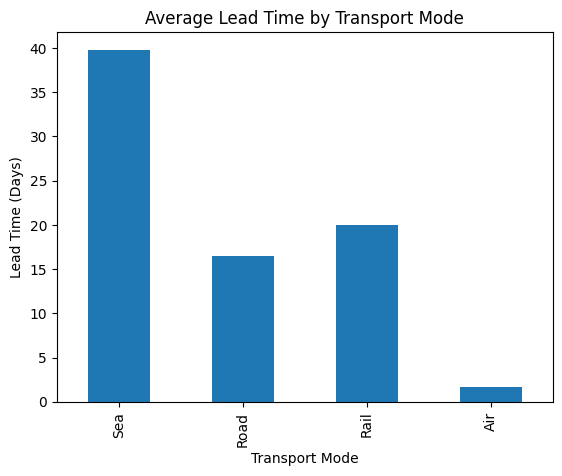

In [12]:
query = """
SELECT *
FROM analytics.v_lead_time_by_transport
"""

df_transport = pd.read_sql(query, conn)

df_transport.plot(
    x="transport_mode",
    y="avg_lead_time",
    kind="bar",
    legend=False
)

plt.title("Average Lead Time by Transport Mode")
plt.ylabel("Lead Time (Days)")
plt.xlabel("Transport Mode")
plt.show()

## Shipment Volume by Transport Mode

C:\Users\behlu\AppData\Local\Temp\ipykernel_15604\4268506749.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_transport = pd.read_sql(query, conn)


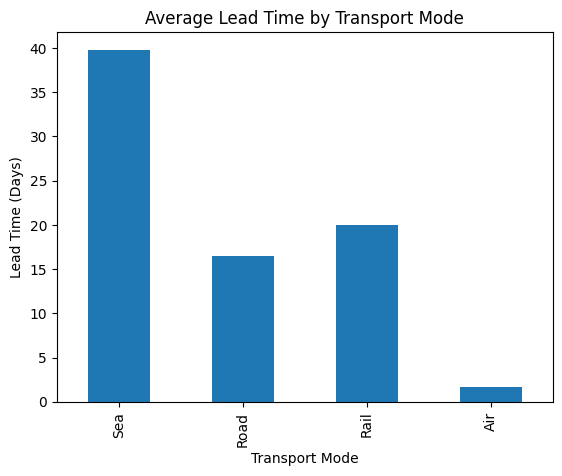

In [13]:
query = """
SELECT *
FROM analytics.v_lead_time_by_transport
"""

df_transport = pd.read_sql(query, conn)

df_transport.plot(
    x="transport_mode",
    y="avg_lead_time",
    kind="bar",
    legend=False
)

plt.title("Average Lead Time by Transport Mode")
plt.ylabel("Lead Time (Days)")
plt.xlabel("Transport Mode")
plt.show()

## Shipment Trends Over Time

C:\Users\behlu\AppData\Local\Temp\ipykernel_15604\1936002063.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_shipments_transport = pd.read_sql(query, conn)


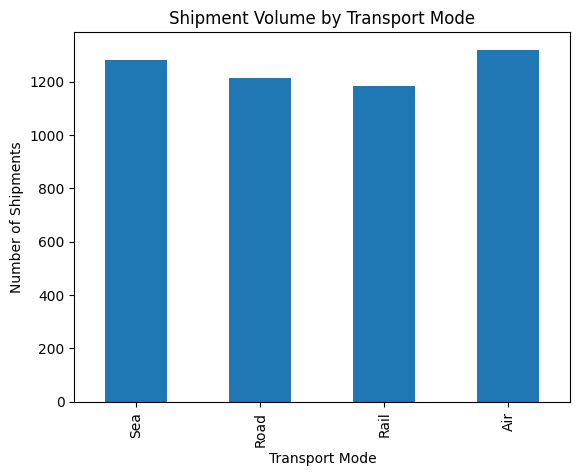

In [14]:
query = """
SELECT *
FROM analytics.v_shipments_by_transport
"""

df_shipments_transport = pd.read_sql(query, conn)

df_shipments_transport.plot(
    x="transport_mode",
    y="shipments",
    kind="bar",
    legend=False
)

plt.title("Shipment Volume by Transport Mode")
plt.ylabel("Number of Shipments")
plt.xlabel("Transport Mode")
plt.show()

## Port Performance

C:\Users\behlu\AppData\Local\Temp\ipykernel_15604\3838576227.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_month = pd.read_sql(query, conn)


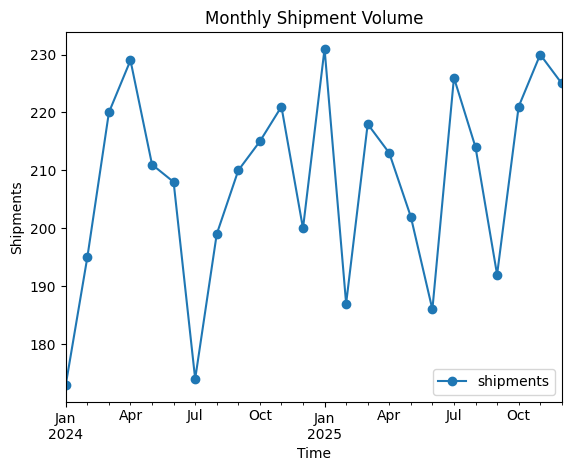

In [15]:
query = """
SELECT *
FROM analytics.v_shipments_by_month
"""

df_month = pd.read_sql(query, conn)

df_month["date"] = pd.to_datetime(df_month["year"].astype(str) + "-" + df_month["month"].astype(str))

df_month.plot(
    x="date",
    y="shipments",
    kind="line",
    marker="o"
)

plt.title("Monthly Shipment Volume")
plt.ylabel("Shipments")
plt.xlabel("Time")
plt.show()

## Product Category Analysis

C:\Users\behlu\AppData\Local\Temp\ipykernel_15604\1439382207.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_ports = pd.read_sql(query, conn)


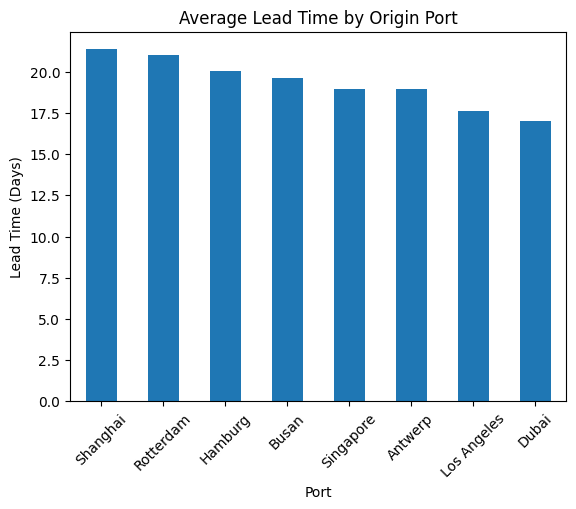

In [16]:
query = """
SELECT *
FROM analytics.v_lead_time_by_port
"""

df_ports = pd.read_sql(query, conn)

df_ports.sort_values("avg_lead_time", ascending=False).plot(
    x="port_name",
    y="avg_lead_time",
    kind="bar",
    legend=False
)

plt.title("Average Lead Time by Origin Port")
plt.ylabel("Lead Time (Days)")
plt.xlabel("Port")
plt.xticks(rotation=45)
plt.show()

## Weather Disruption Analysis

C:\Users\behlu\AppData\Local\Temp\ipykernel_15604\160651961.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_product = pd.read_sql(query, conn)


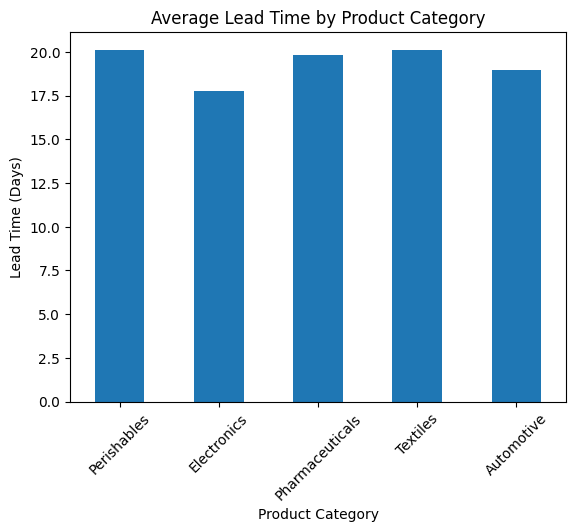

In [17]:
query = """
SELECT *
FROM analytics.v_lead_time_by_product
"""

df_product = pd.read_sql(query, conn)

df_product.plot(
    x="product_category",
    y="avg_lead_time",
    kind="bar",
    legend=False
)

plt.title("Average Lead Time by Product Category")
plt.ylabel("Lead Time (Days)")
plt.xlabel("Product Category")
plt.xticks(rotation=45)
plt.show()

## Distance vs Lead Time

C:\Users\behlu\AppData\Local\Temp\ipykernel_15604\3499521602.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_weather = pd.read_sql(query, conn)


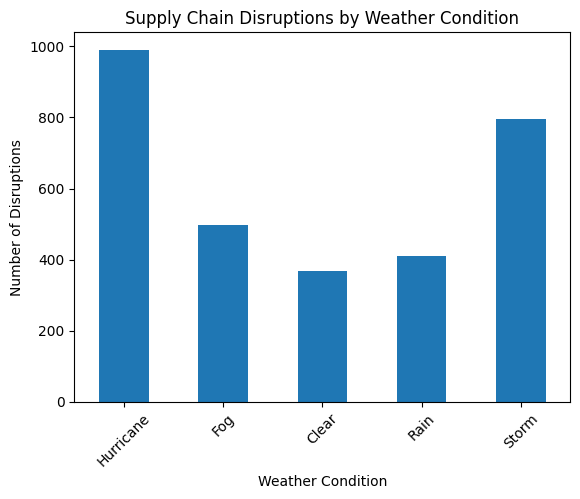

In [18]:
query = """
SELECT *
FROM analytics.v_weather_disruptions
"""

df_weather = pd.read_sql(query, conn)

df_weather.plot(
    x="weather_condition",
    y="disruptions",
    kind="bar",
    legend=False
)

plt.title("Supply Chain Disruptions by Weather Condition")
plt.ylabel("Number of Disruptions")
plt.xlabel("Weather Condition")
plt.xticks(rotation=45)
plt.show()

## Distance vs Lead Time

C:\Users\behlu\AppData\Local\Temp\ipykernel_15604\3228765410.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_distance = pd.read_sql(query, conn)


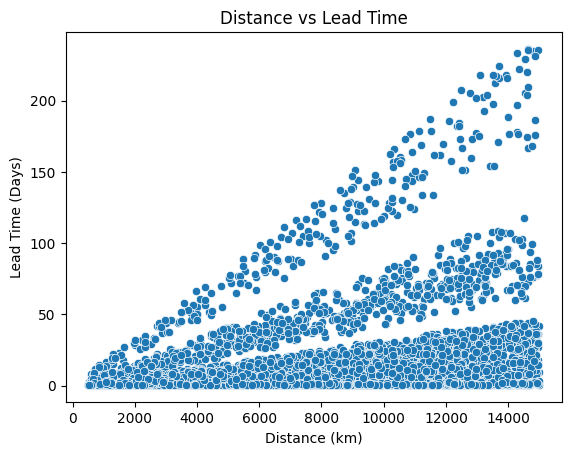

In [19]:
query = """
SELECT *
FROM analytics.v_distance_vs_lead_time
"""

df_distance = pd.read_sql(query, conn)

sns.scatterplot(
    data=df_distance,
    x="distance_km",
    y="lead_time_days"
)

plt.title("Distance vs Lead Time")
plt.xlabel("Distance (km)")
plt.ylabel("Lead Time (Days)")
plt.show()

## Geopolitical Risk Impact

C:\Users\behlu\AppData\Local\Temp\ipykernel_15604\114426099.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_reliability = pd.read_sql(query, conn)


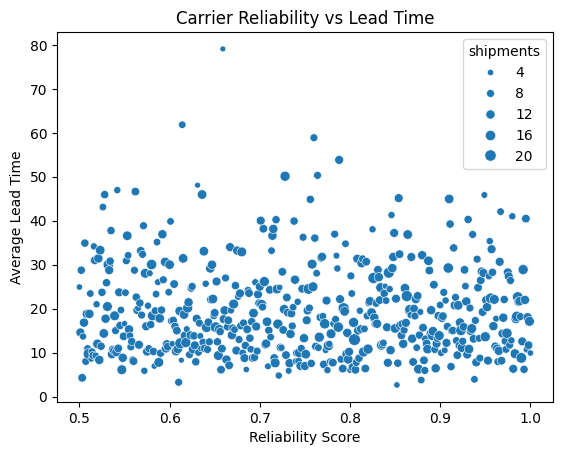

In [20]:
query = """
SELECT *
FROM analytics.v_reliability_analysis
"""

df_reliability = pd.read_sql(query, conn)

sns.scatterplot(
    data=df_reliability,
    x="carrier_reliability_score",
    y="avg_lead_time",
    size="shipments"
)

plt.title("Carrier Reliability vs Lead Time")
plt.xlabel("Reliability Score")
plt.ylabel("Average Lead Time")
plt.show()

## Correlation Analysis

C:\Users\behlu\AppData\Local\Temp\ipykernel_15604\1961060705.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_risk = pd.read_sql(query, conn)


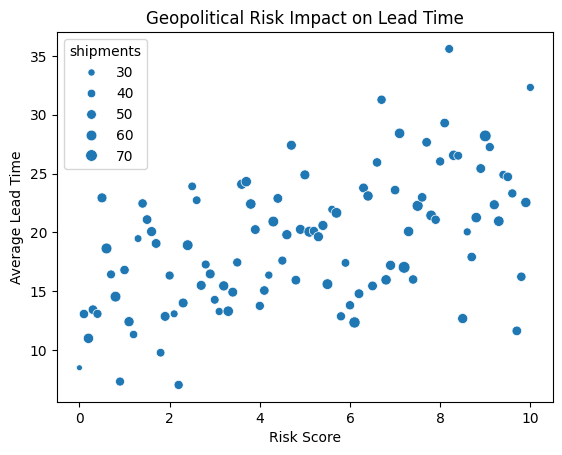

In [21]:
query = """
SELECT *
FROM analytics.v_risk_score_analysis
"""

df_risk = pd.read_sql(query, conn)

sns.scatterplot(
    data=df_risk,
    x="geopolitical_risk_score",
    y="avg_lead_time",
    size="shipments"
)

plt.title("Geopolitical Risk Impact on Lead Time")
plt.xlabel("Risk Score")
plt.ylabel("Average Lead Time")
plt.show()